# Q3 Portfolio Optimization Framework
###   *by Dr. W. Vera-Tudela*

## 1. Introduction & Objective

This is a custom portfolio optimizer framework built from scratch in Jupyter Notebook with supporting functions in a separate Python file. The framework calculates the volatility and returns of a portfolio with assets of equal weight, then proceeds to optimize the weights using the Markowitz and Black-Litterman models.

Objectives:
- Provide an evidence-based decision-making tool: Test your trading hypotheses with historical data.
- Allow strategy refinement: Identify strengths and weaknesses in your approach.
- Risk management: Understand potential returns and their respective volatility.
- Performance comparison: Benchmark the portfolio against two optimization methods.
- Flexibility: Custom-built framework allows for complete control over testing parameters.

This framework provides a solid foundation for quantitative trading strategy development and evaluation.


## 2. Data Pipeline

The structure of the data flow is as follows:

1. Data Management
    - Fetches and cleans real market data from Yahoo Finance
    - Handles historical price data for the "Magnificent 7" assets and SPY
    - Stores processed data for efficient reuse  

2. Asset Checking and Signal Generation
    - Computing daily returns
    - Annualizing returns, volatility, and covariance matrix
    - Plotting correlation and covariance heatmaps 

3. Efficient Frontier - Markowitz model
    - Calculating the weighted returns and volatility
    - Computing the frontier curves for a range of returns
    - Monte Carlo simulation to generate 10,000 random portfolios 

4. Key portfolios
    - Equal weights portfolio: Baseline benchmark
    - Target return optimization: same return as equal weight, minimized volatility
    - Minimum variance portfolio: Leftmost point of frontier
    - Max. Sharpe portfolio: Unconstrained Sharpe maximization

5. Black-Litterman model
    - Market cap weights - equilibrium returns
    - View matrix P, view vector Q, confidence Ω
    - Posterior returns and calculation of μ_BL
    - Rerun optimization with μ_BL
    - Sensitivity test

6. Visualisation
    - Frontier plot with Monte Carlo coloured by Sharpe
        -  Individual assets
        -  Max. Sharpe
        -  MVP
        -  Capital Market Line
    - Portfolio value over 5 years, with key portfolios shown
    - Weight distribution from the different methods for all assets

This consolidated framework provides a complete pipeline from data acquisition through strategy testing to performance evaluation and visualization.  

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

import sys
sys.path.append('../utils')   # path relative to the notebook
from Q3_functions import returns_volatility, frontier_optimizer, max_sharpe, portfolio_return, portfolio_volatility, min_variance, portfolio_value
from common import fetch_portfolio_data, market_cap

## 3. Signal Generation

The first thing to do is to download the historical data for a given time period for all the assets in the portfolio, then clean it to remove incomplete values and keep only the 'Close' columns.  
This is done by the function `fetch_portfolio_data()`.

In addition, the market cap for each asset in the portfolio is downloaded for later use.
This is done by the function `market_cap()`.

Subsequently, returns, volatility and covariance are calculated. Displaying matrices as a plot for ease of analysis.  
This is done by the function `returns_volatility()`.

In [2]:
# Load data
starting_capital = 1_000_000
period = 5
end = pd.Timestamp.today(tz="UTC").normalize()
start = end - pd.DateOffset(years=period)

# tickers = ['BTC-USD', 'ETH-USD', 'SOL-USD', 'BNB-USD', 'XRP-USD', 'ADA-USD', 'TRX-USD', 'DOGE-USD', 'USDC-USD']
# tickers = ['BTC-USD', 'ETH-USD', 'SOL-USD', 'BNB-USD', 'XRP-USD', 'ADA-USD', 'TRX-USD', 'DOGE-USD']
# tickers = ['BTC-USD', 'ETH-USD', 'SOL-USD', 'BNB-USD', 'ADA-USD', 'TRX-USD', 'DOGE-USD']
# tickers = ['BTC-USD', 'ETH-USD', 'SOL-USD', 'BNB-USD', 'TRX-USD', 'DOGE-USD']
# tickers = ['BTC-USD', 'SOL-USD', 'BNB-USD', 'TRX-USD', 'DOGE-USD']
tickers = ['BTC-USD', 'SOL-USD', 'BNB-USD', 'TRX-USD']

dataC, _ = fetch_portfolio_data(tickers, start, end)
assets = dataC.columns.tolist() #tickers sorted in alphabetical order, use this from now on
capsC = market_cap(tickers)

dataS, _ = fetch_portfolio_data('SPY', start, end)

display(dataC.describe())

Ticker,BNB-USD,BTC-USD,SOL-USD,TRX-USD
count,1826.000000,1826.000000,1826.000000,1826.000000
mean,491.563225,56949.925134,105.013943,0.151738
std,218.105316,29905.969873,67.540648,0.098277
min,197.042999,15787.284180,9.651783,0.050036
25%,301.595520,29410.323730,33.390458,0.069303
50%,482.102036,50797.027344,101.841343,0.106532
75%,625.909424,78680.958984,156.976654,0.246406
max,1310.214355,124752.531250,261.869751,0.425992


,Annualized_Return,Annualized_Volatility
Ticker,,
BNB-USD,0.217449,0.504451
BTC-USD,0.180196,0.443990
SOL-USD,0.511437,0.821471
TRX-USD,0.418223,0.575887


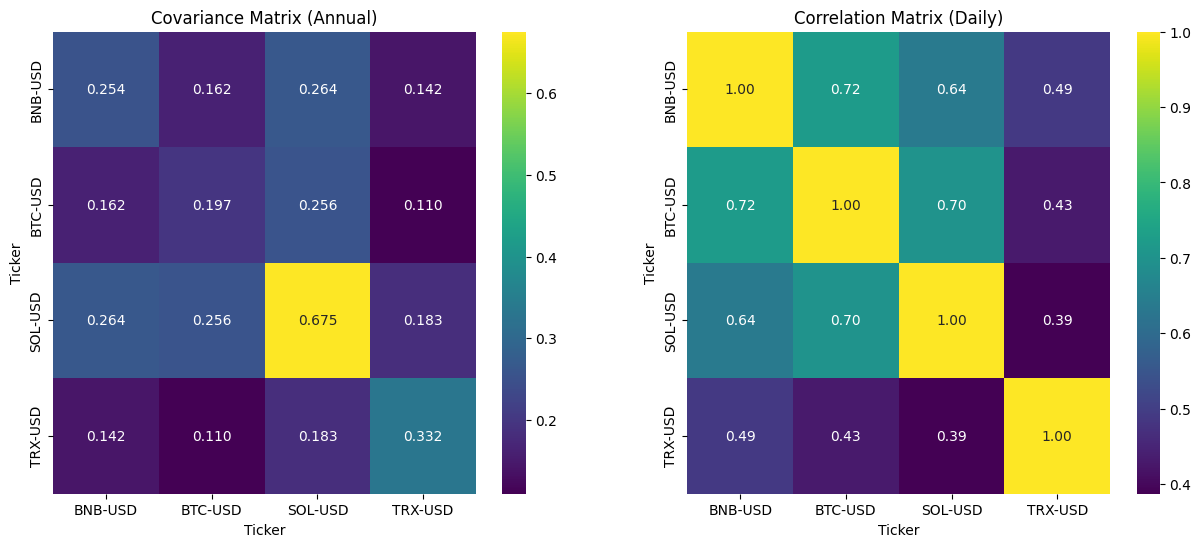

In [3]:
mu_annual, sigma_annual, cov_annual, cov_matrix, corr_matrix = returns_volatility(dataC)

## 4. Efficient Frontier - Markowitz Model

Once the data and signals have been prepared and checked, we move on to the optimization.  

First, the minimum and maximum annual returns are calculated to generate the target returns vector.

Then the frontier values are calculated, 'frontier_volatilities', 'frontier_returns', and 'frontier_weights' to generate the curve.
This is done by the function `frontier_optimizer()`.

Once the frontier is defined, thousands of random portfolios are calculated using the Monte Carlo simulation method.

In [4]:
return_min = mu_annual.min()  # lowest individual asset return
return_max = mu_annual.max()  # highest individual asset return
target_returns = np.linspace(return_min, return_max, 100)
frontier_volatilities, frontier_returns, frontier_weights = frontier_optimizer(mu_annual, sigma_annual, cov_annual, target_returns)

In [5]:
n_simulations = 10_000
sim_returns, sim_vols, sim_sharpes = [], [], []

for _ in range(n_simulations):
    w = np.random.dirichlet(np.ones(len(assets)))
    r = portfolio_return(w, mu_annual)
    v = portfolio_volatility(w, cov_annual)
    s = (r - 0.04) / v
    sim_returns.append(r)
    sim_vols.append(v)
    sim_sharpes.append(s)

## 5. Key Portfolios

After the frontier and random portfolios are calculated, we proceed to calculate the key portfolios for comparison.
   - The first is the portfolio with equally distributed weight. This will serve as a benchmark, as it has not been optimized.
   - The second optimizes the target return, aiming to minimize volatility but to obtain the same returns as the benchmark.
   - The third finds the portfolio with the absolute minimum volatility, the leftmost point on the frontier curve.
   - The fourth optimizes the Sharpe ratio without any constraints.

In [9]:
# Equal-weight portfolio

w_equal = np.ones(len(assets)) / len(assets)

# Equal weight portfolio stats
w_equal = np.ones(len(assets)) / len(assets)
ret_equal = portfolio_return(w_equal, mu_annual)
vol_equal = portfolio_volatility(w_equal, cov_annual)
sharpe_equal = (ret_equal - 0.04) / vol_equal

# display(pd.Series(w_equal, index=assets).round(4))

port_value_eq = portfolio_value(ret_equal, vol_equal, end)

In [11]:
# Optimizing the portfolio weight to obtain the same returns as the equally distributed weights but minimizing the volatility

# Now find the frontier portfolio at the same return
result = min_variance(ret_equal, mu_annual, cov_annual)
w_optimized = result.x
vol_optimized = portfolio_volatility(w_optimized, cov_annual)

print(f"Equal weight: ret={ret_equal:.3f}, vol={vol_equal:.3f}, sharpe={sharpe_equal:.3f}")
print(f"Optimized:    ret={ret_equal:.3f}, vol={vol_optimized:.3f}")
print(f"Volatility reduction: {(vol_optimized/vol_equal - 1)*100:.1f}%")

# display(pd.Series(w_optimized, index=assets).round(4))

port_value_op = portfolio_value(ret_equal, vol_optimized, end)

Equal weight: ret=0.332, vol=0.480, sharpe=0.608
Optimized:    ret=0.332, vol=0.451
Volatility reduction: -6.2%


In [13]:
# calculating the case with the minimum volatility from the efficient frontier

idx = np.argmin(frontier_volatilities)
min_vol = frontier_volatilities[idx]
min_ret = frontier_returns[idx]
min_w = frontier_weights[idx]


print(f"Returns: {min_ret:.4f}")
print(f"Min. Volatility: {min_vol:.4f}")


# display(pd.Series(min_w, index=assets).round(4))

port_value_mi = portfolio_value(min_ret, min_vol, end)

Returns: 0.2438
Min. Volatility: 0.4125


In [19]:
# calculating the weights for maximum Sharpe value
    
sharpe_result = max_sharpe(mu_annual, cov_annual)
sharpe_weights = sharpe_result.x
sharpe_ret = portfolio_return(sharpe_weights, mu_annual)
sharpe_vol = portfolio_volatility(sharpe_weights, cov_annual)


print(f"Sharpe Returns: {sharpe_ret:.4f}")
print(f"Sharpe Volatility: {sharpe_vol:.4f}")
print(f"Sharpe Ratio: {-sharpe_result.fun:.4f}")


# display(pd.Series(sharpe_weights, index=assets).round(4))

port_value_sh = portfolio_value(sharpe_ret, sharpe_vol, end)

Sharpe Returns: 0.4499
Sharpe Volatility: 0.5519
Sharpe Ratio: 0.7426


## 6. Black-Litterman Model

After finishing the previous calculation and seeing some limitations of the Markowitz model, we ran a few extra calculations.
    - The current market cap values are used to calculate weights for each of the assets.
    - Outperformers and underperformers are selected, as well as an outerperformance percentage.
    - Posterior returns are calculated, and the optimization is rerun with the new values.
    - Sensitivity test


The signs indicate direction — positive assets are expected to outperform, negative ones underperform. Normalized weights ensure the view is about *relative* performance, not absolute levels.

**The full Black-Litterman formula for posterior returns:**

μ_BL = [(τΣ)⁻¹ + P^T Ω⁻¹ P]⁻¹ × [(τΣ)⁻¹ π + P^T Ω⁻¹ Q]


In [14]:
# Step 1 - Market cap weights
w_market = capsC["MarketCap"]/capsC["MarketCap"].sum()

# display(pd.Series(w_market.values, index=assets).round(4))

# Step 2 - Equilibrium returns
lam = 2.5
pi = lam * cov_annual @ w_market

# Step 3 - Black-Litterman posterior
tau = 0.05

# Outperformers get +1/4, underperformers get -1/3
# (normalized so each side sums to 1)
P = np.array([[0, -1, +1/2, +1/2]])
#              
Q = np.array([0.10]) # 5% outperformance
omega = tau * P @ cov_annual @ P.T  # proportional to variance of views

# second run
# omega = np.diag([0.001])  # high confidence, small uncertainty
# Q = np.array([0.10])  # you believe 10% outperformance

# Posterior returns
M1 = np.linalg.inv(tau * cov_annual)
M2 = P.T @ np.linalg.inv(omega) @ P
M3 = M1 @ pi + P.T @ np.linalg.inv(omega) @ Q
mu_bl = np.linalg.solve(M1 + M2, M3)

display(pd.DataFrame({"Ticker": pi.index, "pi": pi.values, "mu_bl": mu_bl}))

,Ticker,pi,mu_bl
0,BNB-USD,0.423467,0.436048
1,BTC-USD,0.487239,0.482926
2,SOL-USD,0.665892,0.718604
3,TRX-USD,0.296082,0.340997


In [16]:
# BL optimization

# Market weights
ret_market = portfolio_return(w_market, mu_bl)
vol_market = portfolio_volatility(w_market, cov_annual)
sharpe_market = (ret_market - 0.04) / vol_market


# Now find the frontier portfolio at the same return
result = min_variance(ret_market, mu_bl, cov_annual)
w_optimized_BL = result.x
vol_optimized_BL = portfolio_volatility(w_optimized_BL, cov_annual)

print(f"Market weight: ret={ret_market:.3f}, vol={vol_market:.3f}, sharpe={sharpe_market:.3f}")
print(f"Optimized:     ret={ret_market:.3f}, vol={vol_optimized_BL:.3f}")
print(f"Volatility reduction: {(vol_optimized_BL/vol_market - 1)*100:.1f}%")

display(pd.Series(w_optimized_BL, index=assets).round(4))

port_value_bl = portfolio_value(ret_market, vol_optimized_BL, end)

Market weight: ret=0.451, vol=0.440, sharpe=0.935
Optimized:     ret=0.451, vol=0.415
Volatility reduction: -5.8%


BNB-USD    0.1211
BTC-USD    0.6969
SOL-USD    0.0000
TRX-USD    0.1820
dtype: float64

## 7. Visualisation
Three main plots are show summarizing our findings:
   1. Frontier plot with Monte Carlo coloured by Sharpe showing:
        -  Individual assets
        -  Max. Sharpe
        -  MVP
        -  Capital Market Line
   2. Portfolio value over 5 years showing:
        - Benchmark portfolio
        - Optimized weight for target returns
        - Minimum volatility
        - Maximum Sharpe
        - Black-Litterman optimization
        - SPY as reference
   3. Weight distribution for all assets showing:
        - Benchmark portfolio (equal weights)
        - Optimized weight for target returns
        - Minimum volatility
        - Maximum Sharpe
        - Black-Litterman optimization

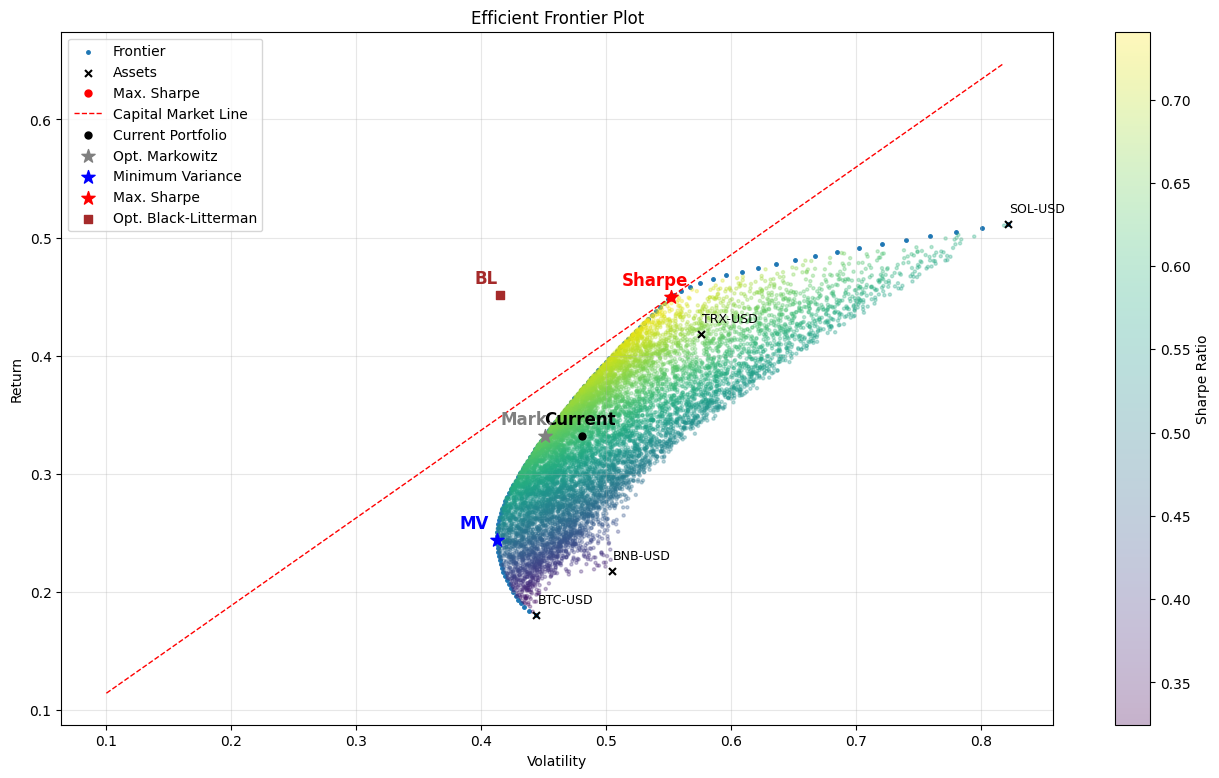

In [20]:
plt.figure(figsize=(16, 9))
colors = sns.color_palette("colorblind")

plt.scatter(frontier_volatilities, frontier_returns, s=25, marker='.', label='Frontier')

plt.scatter(sim_vols, sim_returns, c=sim_sharpes, cmap='viridis', alpha=0.3, s=5)
plt.colorbar(label='Sharpe Ratio')

plt.scatter(sigma_annual, mu_annual, s=25, c='k', marker='x', label='Assets')
for asset in assets:
    plt.annotate(asset, (sigma_annual[asset]+0.001, mu_annual[asset]+0.01),fontsize=9, c='k')

plt.scatter(sharpe_vol, sharpe_ret, s=25, c='r', marker='o', label='Max. Sharpe')

# CML: from (0, rf) through (sharpe_vol, sharpe_ret)
cml_x = np.linspace(0.1, max(sim_vols), 100)
cml_y = 0.04 + (sharpe_ret - 0.04) / sharpe_vol * cml_x
plt.plot(cml_x, cml_y, 'r--', linewidth=1, label='Capital Market Line')

plt.scatter(vol_equal, ret_equal, s=100, c='k', marker='.', label='Current Portfolio')
plt.annotate('Current', (vol_equal-0.03, ret_equal+0.01),fontweight='bold',fontsize=12, color='k')

plt.scatter(vol_optimized, ret_equal, s=100, c='gray', marker='*', label='Opt. Markowitz')
plt.annotate('Mark.', (vol_optimized-0.035, ret_equal+0.01),fontweight='bold',fontsize=12, color='gray')

plt.scatter(min_vol, min_ret, s=100, c='b', marker='*', label='Minimum Variance')
plt.annotate('MV', (min_vol-0.03, min_ret+0.01),fontweight='bold',fontsize=12, color='b')

plt.scatter(sharpe_vol, sharpe_ret, s=100, c='r', marker='*', label='Max. Sharpe')
plt.annotate('Sharpe', (sharpe_vol-0.04, sharpe_ret+0.01),fontweight='bold',fontsize=12, color='r')

plt.scatter(vol_optimized_BL, ret_market, s=40, c='brown', marker='s', label='Opt. Black-Litterman')
plt.annotate('BL', (vol_optimized_BL-0.02, ret_market+0.01),fontweight='bold',fontsize=12, color='brown')

plt.grid(True, alpha=0.3)
plt.xlabel('Volatility')
plt.ylabel('Return')
plt.legend()

plt.title('Efficient Frontier Plot')
plt.show()

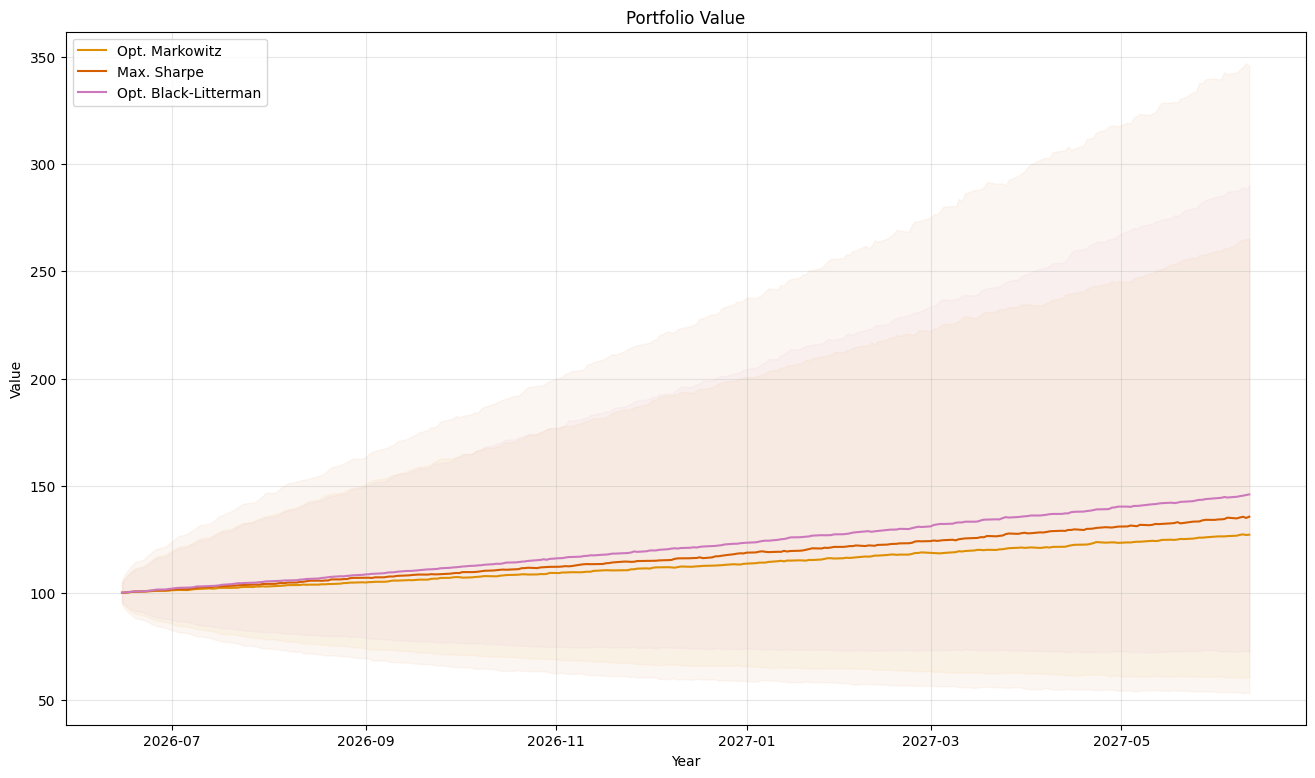

In [21]:
plt.figure(figsize=(16, 9))

colors = sns.color_palette("colorblind")

# plt.plot(port_value_eq.index, port_value_eq.quantile(0.50, axis=1), color=colors[0], label='Current Portfolio')
# plt.fill_between(port_value_eq.index, port_value_eq.quantile(0.05, axis=1), port_value_eq.quantile(0.95, axis=1), color=colors[0], alpha=0.1)

plt.plot(port_value_op.index, port_value_op.quantile(0.50, axis=1), color=colors[1], label='Opt. Markowitz')
plt.fill_between(port_value_op.index, port_value_op.quantile(0.05, axis=1), port_value_op.quantile(0.95, axis=1), color=colors[1], alpha=0.05)

# plt.plot(port_value_mi.index, port_value_mi.quantile(0.50, axis=1), color=colors[2], label='Minimum Variance')
# plt.fill_between(port_value_mi.index, port_value_mi.quantile(0.05, axis=1), port_value_mi.quantile(0.95, axis=1), color=colors[2], alpha=0.1)

plt.plot(port_value_sh.index, port_value_sh.quantile(0.50, axis=1), color=colors[3], label='Max. Sharpe')
plt.fill_between(port_value_sh.index, port_value_sh.quantile(0.05, axis=1), port_value_sh.quantile(0.95, axis=1), color=colors[3], alpha=0.05)

plt.plot(port_value_bl.index, port_value_bl.quantile(0.50, axis=1), color=colors[4], label='Opt. Black-Litterman')
plt.fill_between(port_value_bl.index, port_value_bl.quantile(0.05, axis=1), port_value_bl.quantile(0.95, axis=1), color=colors[4], alpha=0.05)

plt.title('Portfolio Value')
plt.xlabel('Year')
plt.ylabel('Value')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

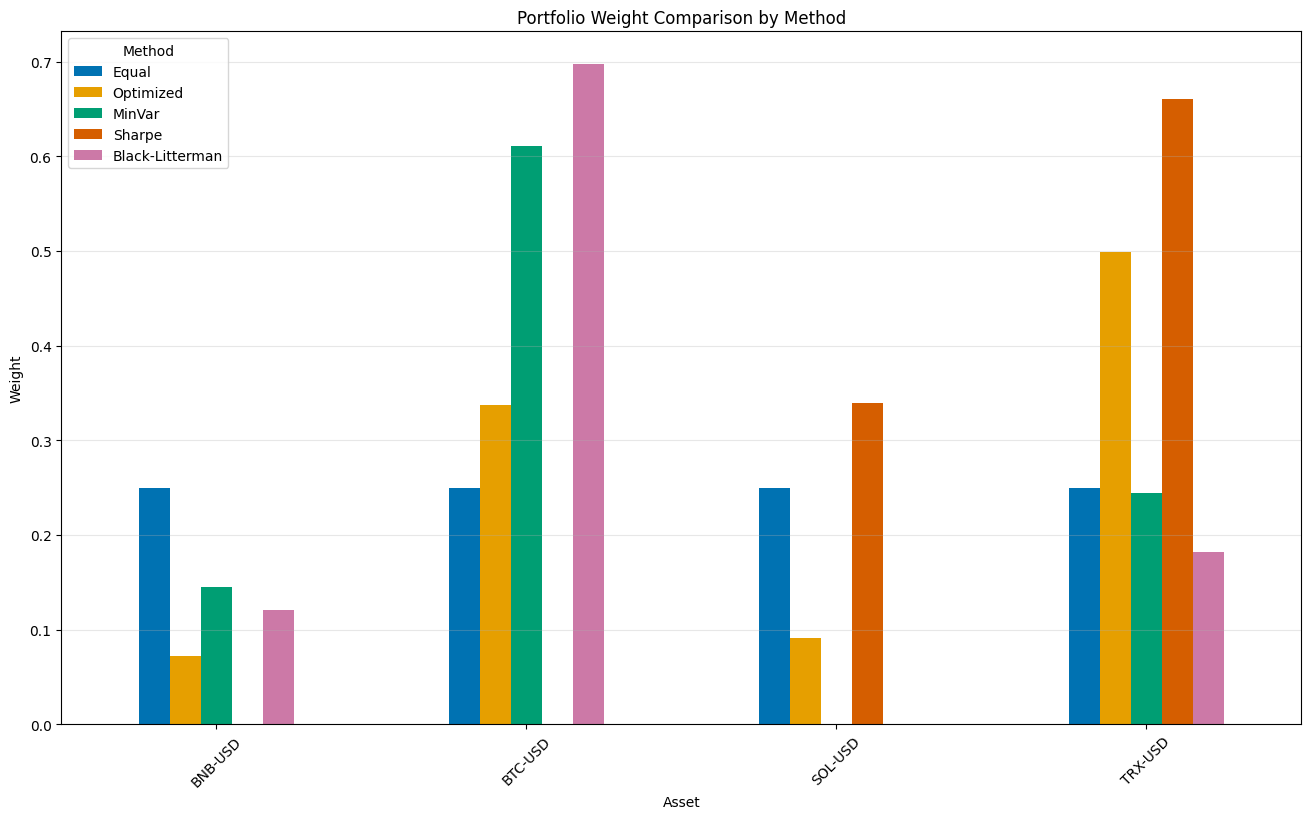

In [22]:
weights_df = pd.DataFrame({
    "Equal": w_equal,
    "Optimized": w_optimized,
    "MinVar": min_w,
    "Sharpe": sharpe_weights,
    "Black-Litterman": w_optimized_BL,
    },
    index=assets
)

colors = [
    "#0072B2", "#E69F00", "#009E73", "#D55E00",
    "#CC79A7", "#F0E442", "#56B4E9", "#000000"
]

weights_df.plot(kind="bar", figsize=(16, 9), color=colors[:len(weights_df.columns)])

plt.title("Portfolio Weight Comparison by Method")
plt.ylabel("Weight")
plt.xlabel("Asset")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Method")

plt.show()